In [1]:
import nugget
import numpy as np
import pickle

In [2]:
geometry = nugget.geometries.EvanescentString.EvanescentString(
            hex_type='hexagonal',
            domain_size=1200,  # diameter/length of the instrumented volume
            dim=3,  # 3D geometry
            n_strings=70,  # Initial number of detector strings (ignored if string_xy is provided)
            points_per_string=20,  # Number of OMs per string
            custom_z_spacing=50, # OM spacing along string (centered around z=0)
            starting_weight =1000,
            active_weights_mode=True # sets all strings with sigmoid(weights) > 0.7 to active (1) and the rest to inactive (0)
        )

visualizer = nugget.utils.vis_tools.Visualizer(
    dim=3, 
    domain_size=2500,
    )

evaluator = nugget.utils.basic_evaluator.Evaluator(
    geometry=geometry,
    visualizer=visualizer,
)

In [3]:
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    rov_rec_width=230,  # ROV dimensions
    rov_height=159.9, 
    rov_tri_length=159.9
)

# code works mostly with dictionaries

# shared parameters for all loss functions
loss_params ={
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
}
# dictionary of loss functions for evaluation and plotting
loss_func_dict = {
    'rov_penalty': rov_penalty,
}
# list of plot types for visualization (see vis_tools.py for available plot types and required inputs)
plot_types = [
    'string_xy_rov_penalty',
]
# extra kwargs for visualization (see vis_tools.py for available kwargs and their meaning)
vis_kwargs = {
    'plot_types': plot_types,
    'zoom_range':900,
    'rov_penalty_func': rov_penalty,
    'rov_draw_safe_space_on_violations':False,
}

In [12]:
# making dictionaries of dictionaries for different geoemtries, for simultaneous evaluation and plotting
geom_dicts = {}
loss_param_dicts = {}
for geom_name in ['600hexagon','default', 'expanded', 'modified', 'large', 'compact']:
    if geom_name != '800main' and geom_name != '600hexagon':
        geom_dict = {'string_xy': np.load(f'../other/{geom_name}_xy.npy')} #requires string_xy (xy), evaluator will initialize other parameters with default values of evanescent geometry object
    elif geom_name == '800main':
        geom_dict = pickle.load(open('600main_r600_50_1_ang_res/geom_16.pkl', 'rb'))
    elif geom_name == '600hexagon':
        geom_dict = {'n_strings': 70} # default evanescent geometry is hexagonal, can readjust number of strings and other parameters if needed,
    geom_dicts[geom_name] = geom_dict
    loss_param_dicts[geom_name] = dict(loss_params)

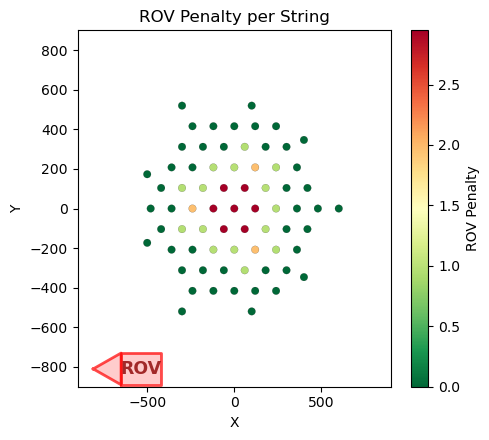

Eval | rov_penalty: 0.561217


In [13]:
# indiviudal evaluation
results = evaluator.evaluate( 
    geom_dict=geom_dicts['600hexagon'],
    loss_func_dict=loss_func_dict,
    loss_params_dict=loss_param_dicts['600hexagon'],
    vis_kwargs=vis_kwargs,
    visualize=True,
)

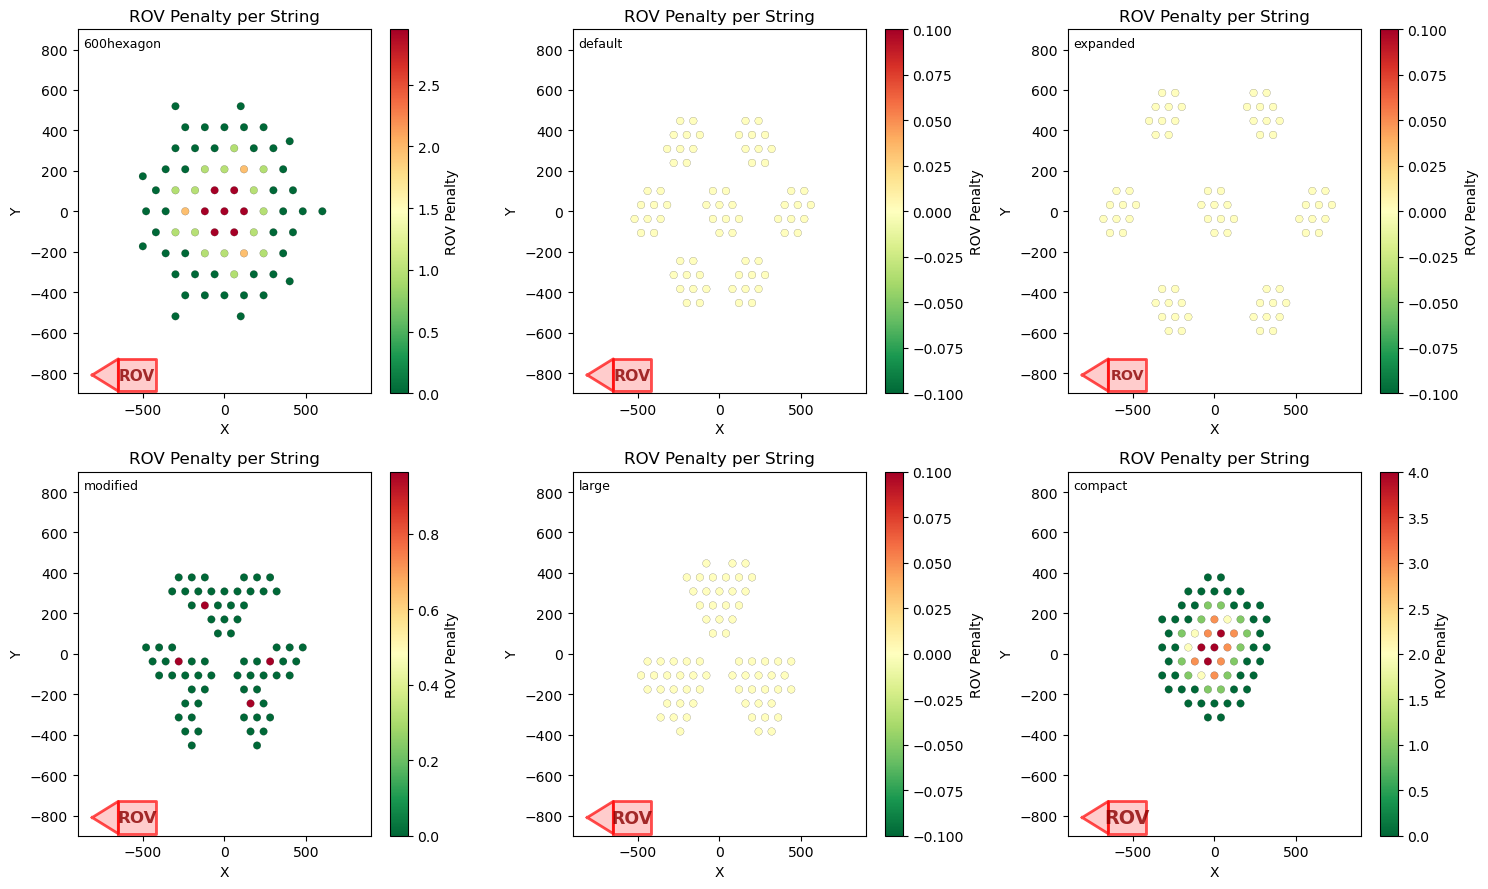

In [14]:
# multi-evaluation
results=evaluator.evaluate_multi(
    geom_dicts=geom_dicts,
    loss_func_dict=loss_func_dict,
    loss_params_dicts=loss_param_dicts,
    vis_kwargs=vis_kwargs,
    visualize=True,
)

In [ ]:
# evaluator returns a dictionary with different results for each geometry including the initiated geometry
results['modified']['geom_dict']

{'points_3d': tensor([[-280.0000,  377.7946, -475.0000],
         [-280.0000,  377.7946, -425.0000],
         [-280.0000,  377.7946, -375.0000],
         ...,
         [ 200.0000, -453.5898,  375.0000],
         [ 200.0000, -453.5898,  425.0000],
         [ 200.0000, -453.5898,  475.0000]]),
 'string_xy': tensor([[-280.0000,  377.7946],
         [-200.0000,  377.7946],
         [-120.0000,  377.7946],
         [ 120.0000,  377.7946],
         [ 200.0000,  377.7946],
         [ 280.0000,  377.7946],
         [-320.0000,  308.5125],
         [-240.0000,  308.5125],
         [-160.0000,  308.5125],
         [ -80.0000,  308.5125],
         [   0.0000,  308.5125],
         [  80.0000,  308.5125],
         [ 160.0000,  308.5125],
         [ 240.0000,  308.5125],
         [ 320.0000,  308.5125],
         [-200.0000,  239.2305],
         [-120.0000,  239.2305],
         [ -40.0000,  239.2305],
         [  40.0000,  239.2305],
         [ 120.0000,  239.2305],
         [ -80.0000,  169.9485],
 